**Import Libraries**

In [2]:
import pandas as pd
import numpy as np

**Loading Dataset**

In [3]:
df = pd.read_csv("Telco-Customer-Churn.csv")

# show first rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Basic Dataset Information**

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Fix Inconsistent Data Types**

In [7]:
#TotalCharges should be numeric, because it represents money paid by the customer.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

**Check Missing Values (Before Cleaning)**




In [8]:
print("Missing values in each column:\n")
print(df.isnull().sum())

Missing values in each column:

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


**Filling with Median**

In [9]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

**Check Missing Values (After Cleaning)**

In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

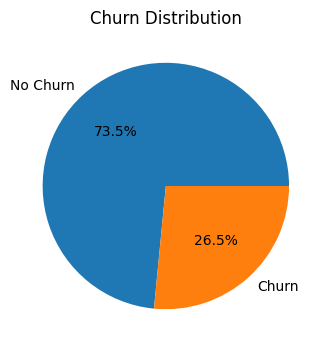

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Churn Count
churn_counts = df["Churn"].value_counts()
plt.figure(figsize=(5, 4))
plt.pie(churn_counts, labels=["No Churn", "Churn"], autopct="%1.1f%%")
plt.title("Churn Distribution")
plt.show()

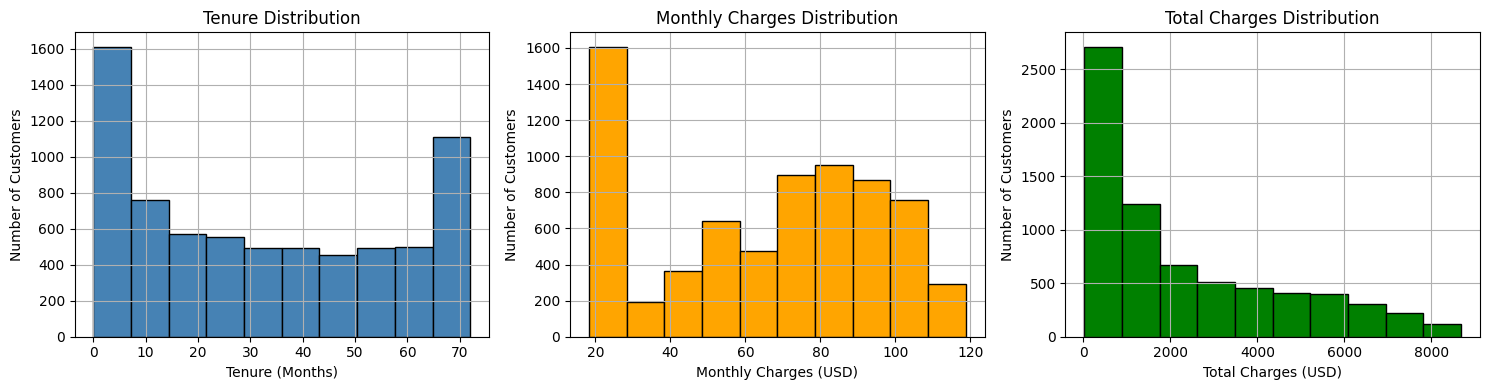

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["tenure"].hist(ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Tenure Distribution")
axes[0].set_xlabel("Tenure (Months)")
axes[0].set_ylabel("Number of Customers")

df["MonthlyCharges"].hist(ax=axes[1], color="orange", edgecolor="black")
axes[1].set_title("Monthly Charges Distribution")
axes[1].set_xlabel("Monthly Charges (USD)")
axes[1].set_ylabel("Number of Customers")

df["TotalCharges"].hist(ax=axes[2], color="green", edgecolor="black")
axes[2].set_title("Total Charges Distribution")
axes[2].set_xlabel("Total Charges (USD)")
axes[2].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

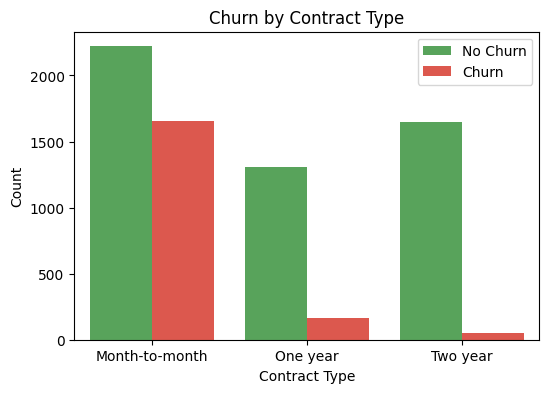

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Contract", hue="Churn", palette=["#4CAF50", "#F44336"])
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.legend(["No Churn", "Churn"])
plt.show()

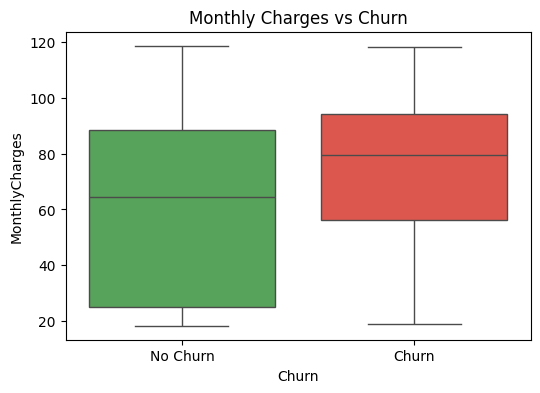

In [14]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn", palette=["#4CAF50", "#F44336"], legend=False)
plt.title("Monthly Charges vs Churn")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.show()

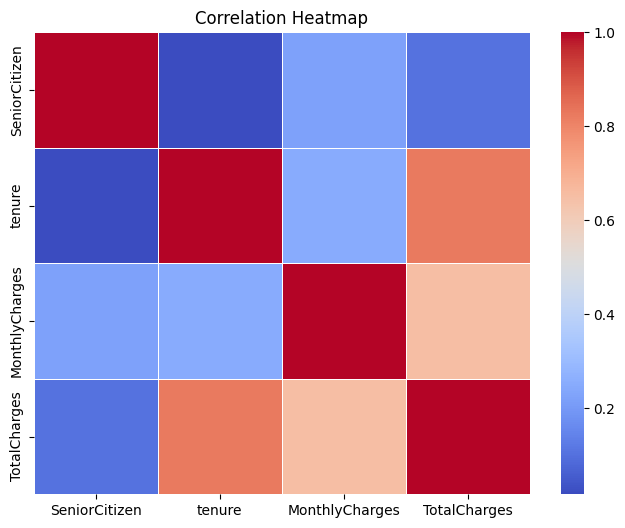

In [15]:
plt.figure(figsize=(8, 6))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

**Check Duplicate Records**

In [16]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [17]:
df = df.drop_duplicates()

**Remove Irrelevant Column**

In [18]:
df = df.drop("customerID", axis=1)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Encode Target Variable (Churn)**

In [19]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

**Encode Binary Columns**

In [20]:
binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

for col in binary_cols:
    df[col] = df[col].map({"Yes":1, "No":0, "Male":1, "Female":0})

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


**One-Hot Encoding for Remaining Categorical Variables**

In [21]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

**Check Class Distribution (Data Imbalance)**

In [23]:
print("Churn distribution:\n")
print(df["Churn"].value_counts())

print("\nPercentage:\n")
print(df["Churn"].value_counts(normalize=True)*100)

Churn distribution:

Churn
0    5174
1    1869
Name: count, dtype: int64

Percentage:

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


**Check Outliers**

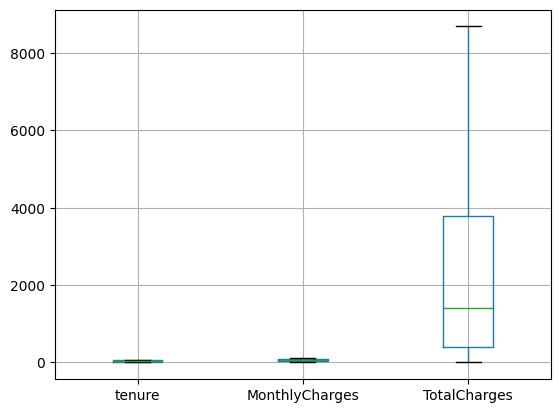

In [24]:
import matplotlib.pyplot as plt

df.boxplot(column=["tenure","MonthlyCharges","TotalCharges"])
plt.show()

**Save Preprocessed Dataset**

In [25]:
df.to_csv("telco_churn_preprocessed.csv", index=False)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.


In [26]:
# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,True,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,False,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,False,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,False,...,False,False,False,False,False,False,False,False,True,False


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(5634, 30) (1409, 30)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
y_pred_lr = lr.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Logistic Regression Results\n")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Results

Accuracy: 0.8197303051809794

Confusion Matrix:
 [[933 103]
 [151 222]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [32]:
lr_balanced = LogisticRegression(class_weight="balanced")
lr_balanced.fit(X_train, y_train)

y_pred_lr_bal = lr_balanced.predict(X_test)

print("Logistic Regression (Balanced)\n")

print("Accuracy:", accuracy_score(y_test, y_pred_lr_bal))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_bal))

print("\nClassification Report:\n", classification_report(y_test, y_pred_lr_bal))

Logistic Regression (Balanced)

Accuracy: 0.7473385379701917

Confusion Matrix:
 [[746 290]
 [ 66 307]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.51      0.82      0.63       373

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=10,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree (Tuned)\n")

print("Train Accuracy:", dt.score(X_train, y_train))
print("Test Accuracy:", dt.score(X_test, y_test))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree (Tuned)

Train Accuracy: 0.7965921192758253
Test Accuracy: 0.8076650106458482

Confusion Matrix:
 [[966  70]
 [201 172]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.93      0.88      1036
           1       0.71      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409



In [34]:
dt_bal = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

dt_bal.fit(X_train, y_train)

y_pred_dt_bal = dt_bal.predict(X_test)

print("Decision Tree (Balanced + Tuned)\n")

print("Train Accuracy:", dt_bal.score(X_train, y_train))
print("Test Accuracy:", dt_bal.score(X_test, y_test))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt_bal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt_bal))

Decision Tree (Balanced + Tuned)

Train Accuracy: 0.7529286474973376
Test Accuracy: 0.7452093683463449

Confusion Matrix:
 [[755 281]
 [ 78 295]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.73      0.81      1036
           1       0.51      0.79      0.62       373

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409



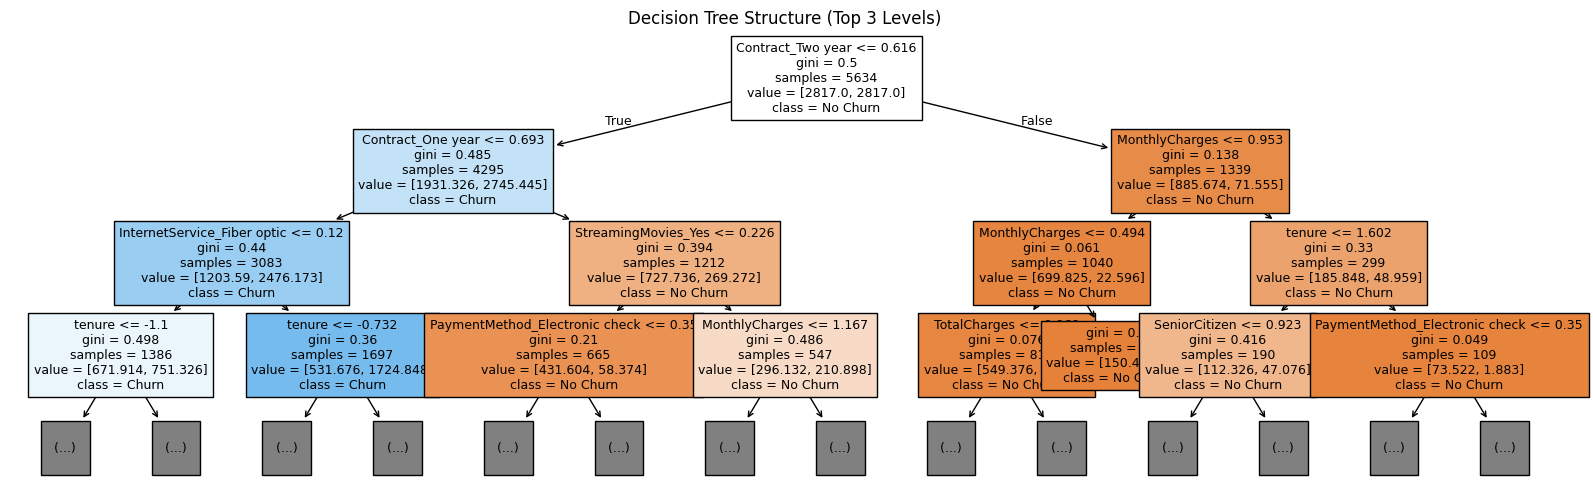

In [35]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 6))
plot_tree(
    dt_bal,
    max_depth=3,               # only show top 3 levels so it's readable
    feature_names=X.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    fontsize=9
)
plt.title("Decision Tree Structure (Top 3 Levels)")
plt.show()

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest (Tuned)\n")

print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest (Tuned)

Train Accuracy: 0.8134540291089812
Test Accuracy: 0.8048261178140526

Confusion Matrix:
 [[953  83]
 [192 181]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.69      0.49      0.57       373

    accuracy                           0.80      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [37]:
rf_bal = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=13,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

rf_bal.fit(X_train, y_train)

y_pred_rf_bal = rf_bal.predict(X_test)

print("Random Forest (Balanced + Tuned)\n")

print("Train Accuracy:", rf_bal.score(X_train, y_train))
print("Test Accuracy:", rf_bal.score(X_test, y_test))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_bal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_bal))

Random Forest (Balanced + Tuned)

Train Accuracy: 0.7600283990060348
Test Accuracy: 0.7551454932576295

Confusion Matrix:
 [[747 289]
 [ 56 317]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.72      0.81      1036
           1       0.52      0.85      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.79      0.73      1409
weighted avg       0.82      0.76      0.77      1409



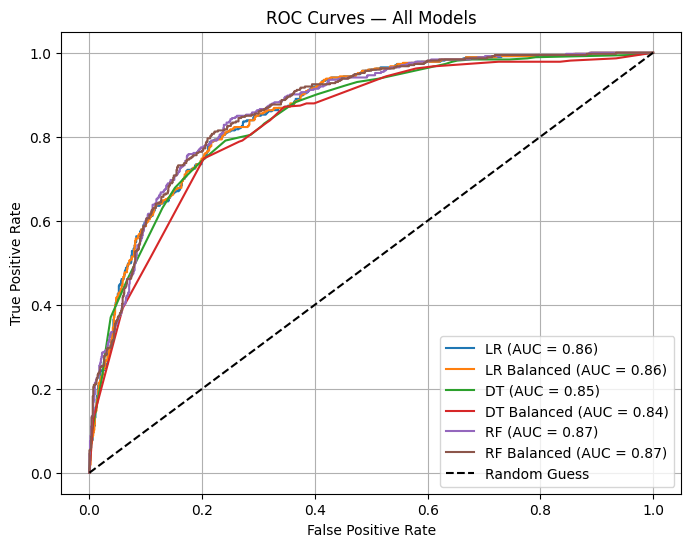

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for each model
lr_probs    = lr.predict_proba(X_test)[:, 1]
lr_bal_probs = lr_balanced.predict_proba(X_test)[:, 1]
dt_probs    = dt.predict_proba(X_test)[:, 1]
dt_bal_probs = dt_bal.predict_proba(X_test)[:, 1]
rf_probs    = rf.predict_proba(X_test)[:, 1]
rf_bal_probs = rf_bal.predict_proba(X_test)[:, 1]

# Compute ROC curves
models = {
    "LR": lr_probs,
    "LR Balanced": lr_bal_probs,
    "DT": dt_probs,
    "DT Balanced": dt_bal_probs,
    "RF": rf_probs,
    "RF Balanced": rf_bal_probs,
}

plt.figure(figsize=(8, 6))

for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [39]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced", None]
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

print("Best Parameters:", rf_tuned.best_params_)
print("Best CV F1 Score:", round(rf_tuned.best_score_, 3))

# Evaluate tuned model
y_pred_tuned = rf_tuned.predict(X_test)
print("\nTuned RF Classification Report:\n")
print(classification_report(y_test, y_pred_tuned))

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10, 'class_weight': 'balanced'}
Best CV F1 Score: 0.632

Tuned RF Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.78      0.84      1036
           1       0.57      0.79      0.66       373

    accuracy                           0.78      1409
   macro avg       0.74      0.79      0.75      1409
weighted avg       0.82      0.78      0.79      1409



In [40]:
from sklearn.model_selection import cross_val_score

print("5-Fold Cross-Validation (F1 Score for Churn class)\n")

models_cv = {
    "Logistic Regression": lr,
    "Logistic Regression (Balanced)": lr_balanced,
    "Decision Tree": dt,
    "Decision Tree (Balanced)": dt_bal,
    "Random Forest": rf,
    "Random Forest (Balanced)": rf_bal,
    "RF (RandomizedSearchCV)" : rf_tuned,
}

for name, model in models_cv.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="f1")
    print(f"{name}: Mean F1 = {scores.mean():.3f} | Std = {scores.std():.3f}")

5-Fold Cross-Validation (F1 Score for Churn class)

Logistic Regression: Mean F1 = 0.592 | Std = 0.018
Logistic Regression (Balanced): Mean F1 = 0.622 | Std = 0.015
Decision Tree: Mean F1 = 0.568 | Std = 0.029
Decision Tree (Balanced): Mean F1 = 0.611 | Std = 0.011
Random Forest: Mean F1 = 0.547 | Std = 0.032
Random Forest (Balanced): Mean F1 = 0.624 | Std = 0.017
RF (RandomizedSearchCV): Mean F1 = 0.632 | Std = 0.011


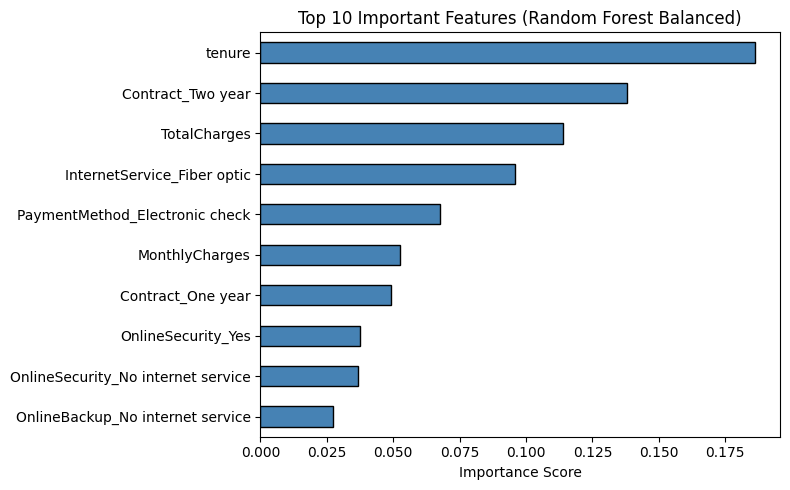

In [41]:
import pandas as pd

feature_importance = rf_bal.feature_importances_
features = X.columns

importance_df = pd.Series(feature_importance, index=features).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importance_df.sort_values().plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Top 10 Important Features (Random Forest Balanced)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [42]:
from sklearn.metrics import f1_score, roc_auc_score

results = {
    "Model": [
        "Logistic Regression",
        "LR (Balanced)",
        "Decision Tree",
        "DT (Balanced)",
        "Random Forest",
        "RF (Balanced)",
        "RF (Tuned)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_lr_bal),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_dt_bal),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_bal),
        accuracy_score(y_test, y_pred_tuned),
    ],
    "F1 Score (Churn)": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr_bal),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt_bal),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_bal),
        f1_score(y_test, y_pred_tuned),
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, lr_bal_probs),
        roc_auc_score(y_test, dt_probs),
        roc_auc_score(y_test, dt_bal_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, rf_bal_probs),
        roc_auc_score(y_test, rf_tuned.predict_proba(X_test)[:, 1]),
    ]
}

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.round(3)
comparison_df

,Model,Accuracy,F1 Score (Churn),ROC-AUC
0,Logistic Regression,0.820,0.636,0.862
1,LR (Balanced),0.747,0.633,0.862
2,Decision Tree,0.808,0.559,0.850
3,DT (Balanced),0.745,0.622,0.836
4,Random Forest,0.805,0.568,0.866
5,RF (Balanced),0.755,0.648,0.866
6,RF (Tuned),0.785,0.660,0.865


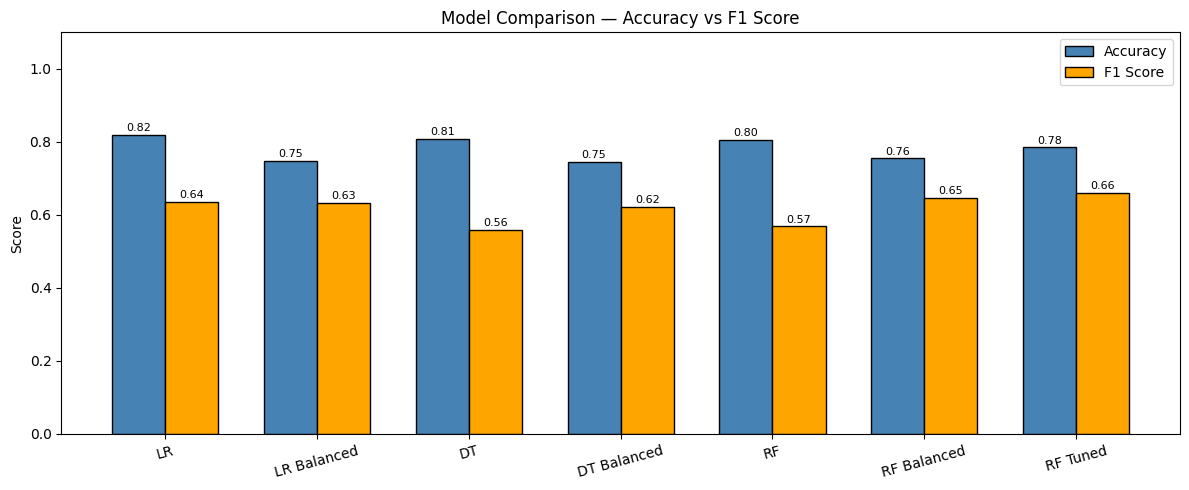

In [43]:
model_names = [
    "LR", "LR Balanced",
    "DT", "DT Balanced",
    "RF", "RF Balanced", "RF Tuned"
]

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_lr_bal),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_dt_bal),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_rf_bal),
    accuracy_score(y_test, y_pred_tuned),
]

f1_scores = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr_bal),
    f1_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt_bal),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf_bal),
    f1_score(y_test, y_pred_tuned),
]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label="Accuracy",    color="steelblue",  edgecolor="black")
bars2 = ax.bar(x + width/2, f1_scores,  width, label="F1 Score",    color="orange",     edgecolor="black")

ax.set_title("Model Comparison — Accuracy vs F1 Score")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

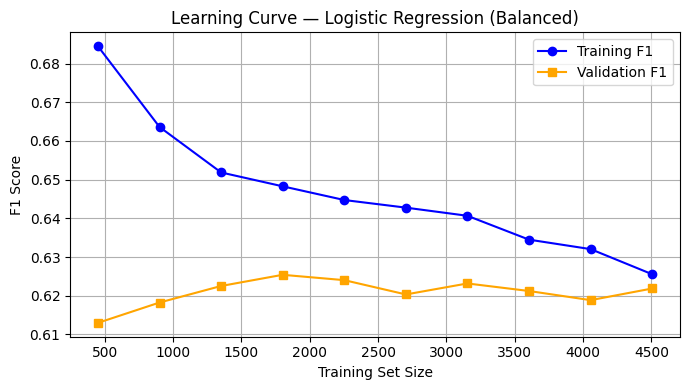

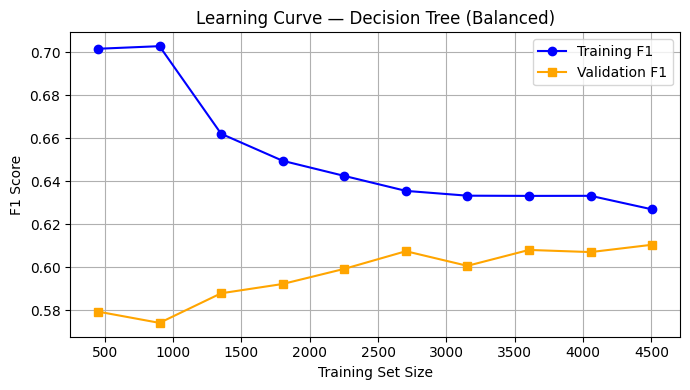

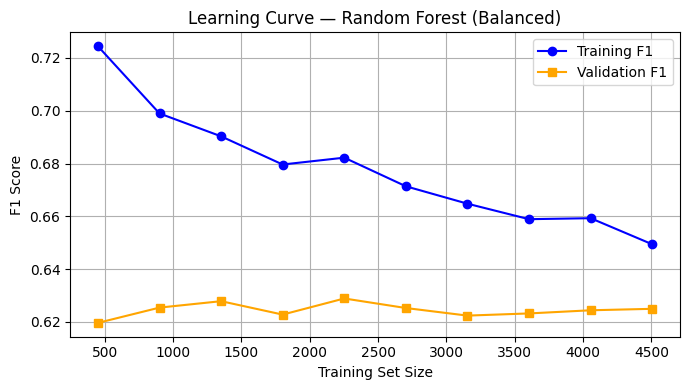

In [44]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring="f1",
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)

    plt.figure(figsize=(7, 4))
    plt.plot(train_sizes, train_mean, label="Training F1",   color="blue",  marker="o")
    plt.plot(train_sizes, val_mean,   label="Validation F1", color="orange", marker="s")
    plt.title(f"Learning Curve — {title}")
    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot for your 3 main models
plot_learning_curve(lr_balanced,  X_train, y_train, "Logistic Regression (Balanced)")
plot_learning_curve(dt_bal,       X_train, y_train, "Decision Tree (Balanced)")
plot_learning_curve(rf_bal,  X_train, y_train, "Random Forest (Balanced)")

In [45]:
import joblib
joblib.dump(rf_bal, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Model and scaler saved!")

Model and scaler saved!


In [49]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score
import pandas as pd

# ── Predicted probabilities for ROC-AUC ───────────────────
lr_probs     = lr.predict_proba(X_test)[:, 1]
lr_bal_probs = lr_balanced.predict_proba(X_test)[:, 1]
dt_probs     = dt.predict_proba(X_test)[:, 1]
dt_bal_probs = dt_bal.predict_proba(X_test)[:, 1]
rf_probs     = rf.predict_proba(X_test)[:, 1]
rf_bal_probs = rf_bal.predict_proba(X_test)[:, 1]
rf_tuned_probs = rf_tuned.predict_proba(X_test)[:, 1]

# ── All predictions ────────────────────────────────────────
predictions = {
    "Logistic Regression":     (y_pred_lr,      lr_probs),
    "LR (Balanced)":           (y_pred_lr_bal,  lr_bal_probs),
    "Decision Tree":           (y_pred_dt,      dt_probs),
    "DT (Balanced)":           (y_pred_dt_bal,  dt_bal_probs),
    "Random Forest":           (y_pred_rf,      rf_probs),
    "RF (Balanced)":           (y_pred_rf_bal,  rf_bal_probs),
    "RF (RandomizedSearchCV)": (y_pred_tuned,   rf_tuned_probs),
}

# ── Build results table ────────────────────────────────────
results = []
for name, (y_pred, y_prob) in predictions.items():
    results.append({
        "Model":      name,
        "Accuracy":   round(accuracy_score(y_test,  y_pred),          3),
        "Precision":  round(precision_score(y_test, y_pred),          3),
        "Recall":     round(recall_score(y_test,    y_pred),          3),
        "F1 Score":   round(f1_score(y_test,        y_pred),          3),
        "ROC-AUC":    round(roc_auc_score(y_test,   y_prob),          3),
    })

results_df = pd.DataFrame(results)

# ── Highlight best value in each column ───────────────────
def highlight_max(s):
    is_max = s == s.max()
    return ["background-color: #90EE90" if v else "" for v in is_max]

styled = results_df.style\
    .apply(highlight_max, subset=["Accuracy","Precision","Recall","F1 Score","ROC-AUC"])\
    .set_caption("📊 Complete Model Evaluation Summary")\
    .format({"Accuracy": "{:.3f}", "Precision": "{:.3f}",
             "Recall":   "{:.3f}", "F1 Score":  "{:.3f}",
             "ROC-AUC":  "{:.3f}"})

display(styled)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.820,0.683,0.595,0.636,0.862
1,LR (Balanced),0.747,0.514,0.823,0.633,0.862
2,Decision Tree,0.808,0.711,0.461,0.559,0.850
3,DT (Balanced),0.745,0.512,0.791,0.622,0.836
4,Random Forest,0.805,0.686,0.485,0.568,0.866
5,RF (Balanced),0.755,0.523,0.850,0.648,0.866
6,RF (RandomizedSearchCV),0.785,0.568,0.788,0.660,0.865
